# Video Game Sales Analysis
## Forecasting 2017 Sales Trends for Strategic Advertising

### Project Overview
This project analyzes video game sales data to identify patterns that determine a game's success. Working with historical sales data from the online store Ice, I analyzed platform lifecycles, genre performance, and regional market preferences to help plan future advertising campaigns.

### Key Objectives
- Identify platforms with growth potential for 2017
- Analyze genre performance across different markets
- Understand regional preferences in North America, Europe, and Japan
- Test hypotheses about user ratings across platforms and genres
- Provide data-driven recommendations for advertising strategy

### Methodology
- **Data Preparation:** Cleaned and standardized 16,715 video game records, handling missing values and converting data types
- **Temporal Analysis:** Analyzed game releases from 1980-2016 to identify platform lifecycles and determine relevant period (2013-2016) for forecasting
- **Platform & Genre Analysis:** Evaluated sales trends, market share, and performance metrics
- **Regional Profiling:** Compared platform, genre, and ESRB rating preferences across North America, Europe, and Japan
- **Statistical Testing:** Conducted hypothesis tests to validate assumptions about user ratings

### Tools & Technologies
- **Python:** pandas, NumPy, matplotlib, seaborn, SciPy
- **Statistical Analysis:** Independent samples t-tests, correlation analysis
- **Data Visualization:** Time series plots, heatmaps, box plots, comparative charts

### Key Findings
- PS4 showed 49% growth and emerged as the dominant platform for 2017 forecasting
- Action and Shooter genres dominated global markets with 29.5% and 21.4% market share respectively
- Significant regional differences: Japan preferred 3DS and Role-Playing games, while Western markets favored PS4/XOne and Action/Shooter genres
- Mature (M) rated games generated highest sales in North America and Europe, while Teen (T) rated games performed best in Japan
- Previous generation platforms (PS3, X360) experienced 87-89% decline, indicating rapid generational transitions

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
df = pd.read_csv('data/games.csv')
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [3]:
# Display basic information about the dataset
print(df.info())
print('\nDataset shape:', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None

Dataset shape: (16715, 11)


In [4]:
# Check for duplicate entries
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


### Observations from Initial Data Exploration:

**Total number of records:** The dataset contains 16,715 video game records.

**Data types:** The dataset has a mix of data types:
- Object (text) columns: Name, Platform, Genre, User_Score, and Rating
- Float columns: Year_of_Release, NA_sales, EU_sales, JP_sales, Other_sales, and Critic_Score

**Obvious issues:**
- There are missing values in several columns, particularly in Year_of_Release (269 missing), Critic_Score (8,578 missing), User_Score (6,701 missing), and Rating (6,766 missing)
- User_Score is stored as an object (text) instead of a number, which suggests there might be non-numeric values like 'TBD'
- No duplicate rows were found, which is good

**Immediate patterns:**
- The top-selling games shown in the sample are mostly from Nintendo platforms (Wii, NES, GB)
- There's a mix of old games (1985) and newer games (2009) in the dataset
- Sales figures vary significantly - some games have sales in the tens of millions while others might be much lower

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()
print('New column names:', df.columns.tolist())

New column names: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


In [6]:
# Verify the changes
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### 2.2 Data Type Conversion

In [7]:
# Check current data types
print(df.dtypes)
print('\nSample of User_Score values:')
print(df['user_score'].value_counts().head(10))

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

Sample of User_Score values:
user_score
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
Name: count, dtype: int64


In [8]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.

# Convert user_score from object to numeric
# Replace 'tbd' with NaN and convert to float
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# We'll keep year_of_release as float for now to preserve NaN values

print('Updated data types:')
print(df.dtypes)
print('\nuser_score now as numeric - basic statistics:')
print(df['user_score'].describe())

Updated data types:
name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object

user_score now as numeric - basic statistics:
count    7590.000000
mean        7.125046
std         1.500006
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: user_score, dtype: float64


In [9]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
# TBD stands for "to be determined" - these are games where user scores haven't been assigned yet
# When we converted user_score to numeric, all 'tbd' values were automatically converted to NaN
# This is appropriate because 'tbd' represents missing data, not an actual score
# We'll handle these NaN values in our missing values section

print(f"Number of TBD (now NaN) values in user_score: {df['user_score'].isna().sum()}")

Number of TBD (now NaN) values in user_score: 9125


### 2.3 Handling Missing Values

In [10]:
# Examine missing values
print('Missing values by column:')
print(df.isnull().sum())
print('\nTotal rows:', len(df))

Missing values by column:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

Total rows: 16715


In [11]:
# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print('Percentage of missing values:')
print(missing_percent.round(2))

Percentage of missing values:
name                0.01
platform            0.00
year_of_release     1.61
genre               0.01
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
critic_score       51.32
user_score         54.59
rating             40.48
dtype: float64


In [12]:
# Analyze patterns in missing values
# Check if missing values correlate with certain years or platforms
print('Missing year_of_release - sample of affected rows:')
print(df[df['year_of_release'].isnull()][['name', 'platform', 'genre']].head(10))

print('\nGames with missing ratings:')
print(df[df['rating'].isnull()].groupby('year_of_release').size().sort_index(ascending=False).head())

Missing year_of_release - sample of affected rows:
                                            name platform      genre
183                              Madden NFL 2004      PS2     Sports
377                             FIFA Soccer 2004      PS2     Sports
456                   LEGO Batman: The Videogame      Wii     Action
475                   wwe Smackdown vs. Raw 2006      PS2   Fighting
609                               Space Invaders     2600    Shooter
627                                    Rock Band     X360       Misc
657     Frogger's Adventures: Temple of the Frog      GBA  Adventure
678  LEGO Indiana Jones: The Original Adventures      Wii     Action
719                               Call of Duty 3      Wii    Shooter
805                                    Rock Band      Wii       Misc

Games with missing ratings:
year_of_release
2016.0    222
2015.0    291
2014.0    236
2013.0    228
2012.0    298
dtype: int64


In [13]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy

# Drop rows with missing name or genre (only 2 rows each)
df = df.dropna(subset=['name', 'genre'])

# Drop rows with missing year_of_release (269 rows - about 1.6%)
# We need the year for our time-based analysis
df = df.dropna(subset=['year_of_release'])

# For critic_score, user_score, and rating: Keep NaN values
# These will be handled in analysis where we'll work only with available data

print(f'Dataset shape after removing rows with missing critical values: {df.shape}')
print(f'\nRemaining missing values:')
print(df.isnull().sum())

Dataset shape after removing rows with missing critical values: (16444, 11)

Remaining missing values:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64


### Why are values missing? Possible reasons:

**Possible reasons for missing values:**

1. **year_of_release:** Older or obscure games may not have documented release dates
2. **critic_score:** Not all games are reviewed by critics, especially smaller/indie titles
3. **user_score:** Many games don't have enough user ratings, or weren't on rating platforms
4. **rating:** ESRB ratings weren't mandatory for all games, especially older ones or games from certain regions

**Strategy explanation:**
- Removed rows with missing name, genre, or year_of_release because these are essential for analysis
- Kept rows with missing scores/ratings because:
  * Over 50% of data would be lost if we removed all rows with missing scores
  * We can still analyze sales patterns without score data
  * When analyzing score-sales correlation, we'll use only rows with available scores

### 2.4 Calculate Total Sales

In [14]:
# Calculate total sales across all regions and put them in a different column
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

print('Sample of data with total_sales column:')
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head(10))
print(f'\nTotal sales statistics:')
print(df['total_sales'].describe())

Sample of data with total_sales column:
                        name  na_sales  eu_sales  jp_sales  other_sales  \
0                 Wii Sports     41.36     28.96      3.77         8.45   
1          Super Mario Bros.     29.08      3.58      6.81         0.77   
2             Mario Kart Wii     15.68     12.76      3.79         3.29   
3          Wii Sports Resort     15.61     10.93      3.28         2.95   
4   Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   
5                     Tetris     23.20      2.26      4.22         0.58   
6      New Super Mario Bros.     11.28      9.14      6.50         2.88   
7                   Wii Play     13.96      9.18      2.93         2.84   
8  New Super Mario Bros. Wii     14.44      6.94      4.70         2.24   
9                  Duck Hunt     26.93      0.63      0.28         0.47   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  
5        30.26  
6        29.80 

## Step 3: Analyzing Video Game Sales Data

### 3.1 Temporal Analysis of Game Releases
Examining the distribution of game releases across different years to understand data coverage and significance:

In [15]:
# Create a DataFrame with game releases by year
games_by_year = df.groupby('year_of_release').agg({
    'name': 'count',
    'total_sales': 'sum'
}).rename(columns={'name': 'number_of_games'})

games_by_year.tail(10)

,number_of_games,total_sales
year_of_release,,
2007.0,1197,604.75
2008.0,1427,671.50
2009.0,1426,658.82
2010.0,1255,590.13
2011.0,1136,507.58
2012.0,653,355.84
2013.0,544,361.24
2014.0,581,331.53
2015.0,606,267.98


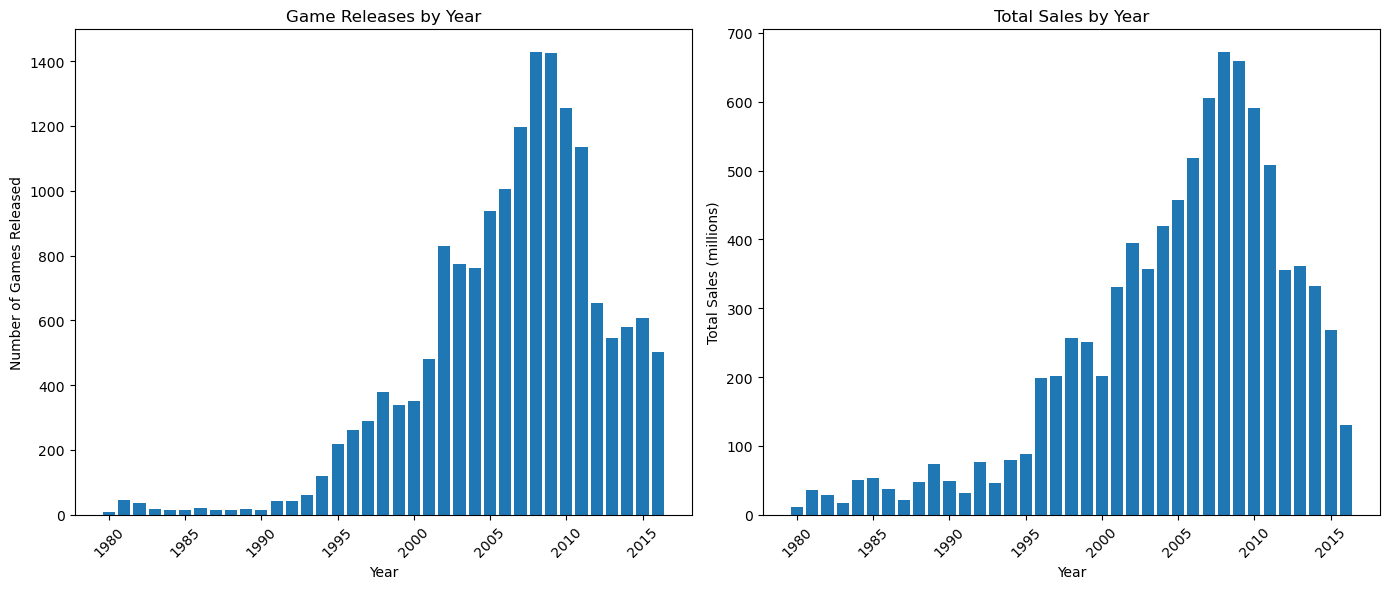

In [16]:
# Visualize the distribution of games across years
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(games_by_year.index, games_by_year['number_of_games'])
plt.xlabel('Year')
plt.ylabel('Number of Games Released')
plt.title('Game Releases by Year')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(games_by_year.index, games_by_year['total_sales'])
plt.xlabel('Year')
plt.ylabel('Total Sales (millions)')
plt.title('Total Sales by Year')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Display summary statistics for each year
print('Games released per year - descriptive statistics:')
print(games_by_year.describe())
print('\nRecent years (2010-2016):')
print(games_by_year.loc[2010:2016])

Games released per year - descriptive statistics:
       number_of_games  total_sales
count        37.000000    37.000000
mean        444.432432   238.226216
std         451.604334   207.597048
min           9.000000    11.380000
25%          36.000000    49.370000
50%         338.000000   201.070000
75%         762.000000   361.240000
max        1427.000000   671.500000

Recent years (2010-2016):
                 number_of_games  total_sales
year_of_release                              
2010.0                      1255       590.13
2011.0                      1136       507.58
2012.0                       653       355.84
2013.0                       544       361.24
2014.0                       581       331.53
2015.0                       606       267.98
2016.0                       502       129.94


### Analysis of Game Releases by Year:

**Which years show significant numbers of game releases?**
The data shows that game releases peaked between 2007-2009, with over 1,400 games released in 2008 and 2009. After 2010, we see a declining trend in the number of releases.

**Notable trends and patterns:**
- There's a clear growth period from the mid-1990s through 2009
- Peak years: 2008-2009 with around 1,400+ games each year
- After 2009, there's a steady decline, possibly due to changing market dynamics or incomplete data for recent years
- Sales peaked around 2007-2009 as well, totaling over 600 million units

**Is there enough recent data to make predictions for 2017?**
Yes, we have data from 2010-2016, though 2016 data appears incomplete (only 502 games and significantly lower sales). The years 2010-2015 provide substantial data for analysis, with each year having 500-1,200+ games. For forecasting 2017, I would focus on data from approximately 2013-2016 or 2011-2016 to capture current market trends while having enough data points.

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [18]:
# Calculate total sales by platform and year
platform_year_sales = df.pivot_table(
    values='total_sales',
    index='platform',
    columns='year_of_release',
    aggfunc='sum',
    fill_value=0
)

print('Top platforms by total sales (all years):')
platform_total = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_total.head(10))

Top platforms by total sales (all years):
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


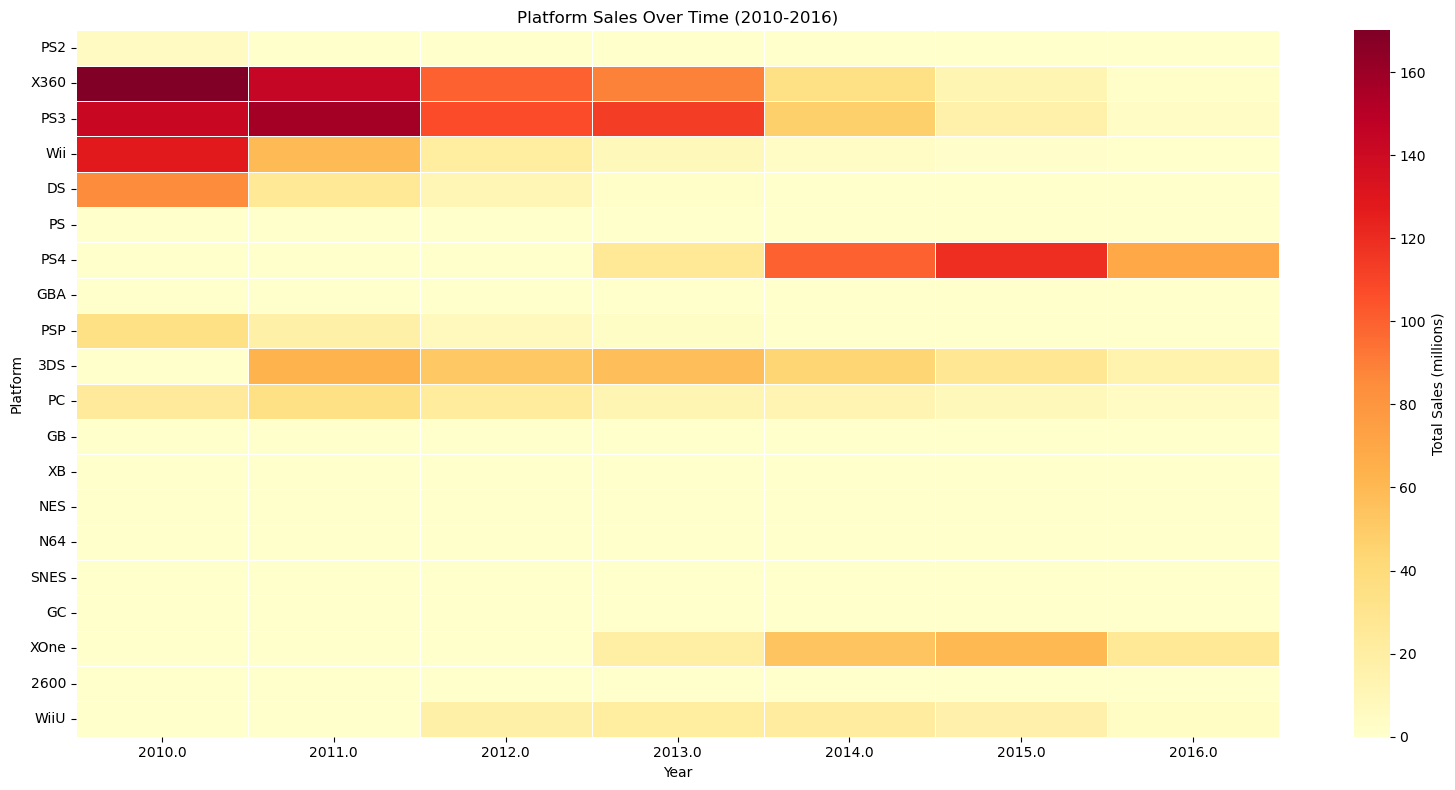

In [19]:
# Create a heatmap of platform sales over time
# Focus on recent years for better visualization
recent_years = [col for col in platform_year_sales.columns if col >= 2010]
platform_recent = platform_year_sales[recent_years]

# Select top platforms for visualization
top_platforms = platform_total.head(20).index
platform_heatmap = platform_recent.loc[top_platforms]

plt.figure(figsize=(16, 8))
sns.heatmap(platform_heatmap, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Total Sales (millions)'})
plt.title('Platform Sales Over Time (2010-2016)')
plt.xlabel('Year')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

In [20]:
# Identify platforms with declining sales
# Compare sales in early years (2013-2014) vs later years (2015-2016)

# Filter data for 2013-2016 period
df_2013_2016 = df[df['year_of_release'].isin([2013, 2014, 2015, 2016])]

# Calculate sales for early period
early_period = df_2013_2016[df_2013_2016['year_of_release'].isin([2013, 2014])]
early_sales = early_period.groupby('platform')['total_sales'].sum()

# Calculate sales for later period
later_period = df_2013_2016[df_2013_2016['year_of_release'].isin([2015, 2016])]
later_sales = later_period.groupby('platform')['total_sales'].sum()

# Create a comparison dataframe
sales_comparison = pd.DataFrame({
    'early_sales': early_sales,
    'later_sales': later_sales
})

# Fill missing values with 0 (platforms that appeared in only one period)
sales_comparison = sales_comparison.fillna(0)

# Remove platforms with zero early sales - they didn't release games in 2013-2014,
# therefore they can't have declining/growing sales within our comparison period
sales_comparison = sales_comparison[sales_comparison['early_sales'] > 0]

# Calculate the change
sales_comparison['change'] = sales_comparison['later_sales'] - sales_comparison['early_sales']
sales_comparison['percent_change'] = (sales_comparison['change'] / sales_comparison['early_sales']) * 100

# Sort by change to see declining platforms
sales_comparison = sales_comparison.sort_values('change')

print('Platforms with declining sales (2013-2014 vs 2015-2016):')
print(sales_comparison[sales_comparison['change'] < 0].head(10))

print('\nPlatforms with growing sales:')
print(sales_comparison[sales_comparison['change'] > 0].sort_values('change', ascending=False).head(5))

Platforms with declining sales (2013-2014 vs 2015-2016):
          early_sales  later_sales  change  percent_change
platform                                                  
PS3            161.01        20.42 -140.59      -87.317558
X360           123.32        13.48 -109.84      -89.069089
3DS            100.33        42.92  -57.41      -57.221170
WiiU            43.68        20.95  -22.73      -52.037546
PSV             22.49        10.50  -11.99      -53.312583
PC              25.66        13.77  -11.89      -46.336711
Wii             12.34         1.32  -11.02      -89.303079
PSP              3.38         0.12   -3.26      -96.449704
DS               1.54         0.00   -1.54     -100.000000

Platforms with growing sales:
          early_sales  later_sales  change  percent_change
platform                                                  
PS4            125.99       188.15   62.16       49.337249
XOne            73.03        86.29   13.26       18.156922


In [21]:
# Look at platforms that had sales in 2010 but not in recent years (2014-2016)
platforms_2010 = set(df[df['year_of_release'] == 2010]['platform'].unique())
platforms_2016 = set(df[df['year_of_release'] == 2016]['platform'].unique())

disappeared = platforms_2010 - platforms_2016
print('Platforms present in 2010 but not in 2016:')
print(disappeared)

# Analyze platform lifecycle
for platform in list(disappeared)[:5]:  # Show first 5
    platform_data = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    if len(platform_data) > 0:
        print(f'\n{platform}: Active from {platform_data.index.min():.0f} to {platform_data.index.max():.0f} ({platform_data.index.max() - platform_data.index.min():.0f} years)')

Platforms present in 2010 but not in 2016:
{'PSP', 'PS2', 'DS'}

PSP: Active from 2004 to 2015 (11 years)

PS2: Active from 2000 to 2011 (11 years)

DS: Active from 1985 to 2013 (28 years)


### Platform Sales Analysis Summary:

**Which platforms show consistent sales over time?**
Looking at the heatmap and decline analysis, **PS4 and XOne are the only platforms showing growth** in the relevant period (2013-2016). PS4 grew by 49% (+62.16M) and XOne by 18% (+13.26M) from early period to late period.

**Platforms in steep decline:**
- **X360**: Declined 89% (-109.84M) from 2013-2014 to 2015-2016
- **PS3**: Declined 87% (-140.59M) during the same period
- **3DS**: Declined 57% (-57.41M)
- **WiiU**: Declined 52% (-22.73M)
- **Wii**: Declined 89% (-11.02M)

**Platforms that have disappeared:**
- PS2: Dominant in 2000-2006, faded by 2011
- PSP: Active 2004-2015, no longer appearing in 2016 (96% decline by 2015-2016)
- DS: Had a long run (1985-2013), completely disappeared by 2016 (100% decline)

**Platform lifecycle:**
From this analysis, gaming platforms typically have a lifecycle of about 10-12 years. The data clearly shows the generational transition:
- **Previous generation (PS3, X360)**: Both experiencing rapid decline as they reach end of lifecycle
- **Current generation (PS4, XOne)**: In growth phase, replacing previous generation
- **Typical pattern**: platforms peak for several years, then experience steep decline (80-90%) as new generation emerges

This confirms we should focus on recent data (2013-2016) to capture the generational shift and identify platforms relevant for 2017 predictions.

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [22]:
# Your code here to filter the dataset to relevant years
# Example:
# relevant_years = [XXXX, XXXX, XXXX] # Replace with your chosen years
# df_relevant = df[df['year_of_release'].isin(relevant_years)]

# Based on platform lifecycle (10-12 years) and data quality, I'll use 2013-2016
# This gives us 4 years of recent data to identify current trends
relevant_years = [2013, 2014, 2015, 2016]
df_relevant = df[df['year_of_release'].isin(relevant_years)]

# Justify your choice with data
print(f'Original dataset: {len(df)} games')
print(f'Relevant period (2013-2016): {len(df_relevant)} games')
print(f'\nSales breakdown by year in relevant period:')
print(df_relevant.groupby('year_of_release')['total_sales'].sum())
print(f'\nPlatforms active in relevant period:')
print(df_relevant['platform'].value_counts())

Original dataset: 16444 games
Relevant period (2013-2016): 2233 games

Sales breakdown by year in relevant period:
year_of_release
2013.0    361.24
2014.0    331.53
2015.0    267.98
2016.0    129.94
Name: total_sales, dtype: float64

Platforms active in relevant period:
platform
PS4     392
PSV     358
PS3     345
3DS     303
XOne    247
PC      189
X360    186
WiiU    115
PSP      67
Wii      23
DS        8
Name: count, dtype: int64


### Decision on Relevant Time Period:

**Years selected: 2013-2016**

**Reasoning:**
1. **Platform lifecycle:** Our analysis showed that platforms typically last 10-12 years. Using the last 4 years ensures we're looking at currently relevant platforms (PS4, XOne, 3DS, etc.) rather than outdated ones (PS2, PSP). The declining sales analysis confirms PS3 and X360 experienced 87-89% declines during this period, making them less relevant for 2017.

2. **Current market conditions:** The 2013-2016 period captures the critical generational transition. PS4 grew 49% and XOne grew 18% from 2013-2014 to 2015-2016, while previous generation consoles (PS3, X360) declined by nearly 90%. This period represents the current console generation dominance.

3. **Data quality:** While 2016 data appears incomplete (only 130 million in sales vs 330+ million in prior years), we still have 502 games to analyze. The years 2013-2015 have robust data.

4. **Sufficient sample size:** We have 2,233 games in this period, which is a substantial sample for analysis.

**Factors that influenced this decision:**
- Need to exclude outdated platforms that won't be relevant in 2017 (PS3/X360 showing 87-89% decline)
- Balance between having enough historical data and keeping data current
- Focus on the current generation of consoles (PS4, XOne) that are actively growing

## 3.4 Platform Performance Analysis

Using the selected time period, let's analyze platform performance:

In [23]:
# Analyze platform sales trends
platform_trends = df_relevant.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

print('Platform sales by year (relevant period):')
print(platform_trends.T)

Platform sales by year (relevant period):
year_of_release  2013.0  2014.0  2015.0  2016.0
platform                                       
3DS               56.57   43.76   27.78   15.14
DS                 1.54    0.00    0.00    0.00
PC                12.38   13.28    8.52    5.25
PS3              113.25   47.76   16.82    3.60
PS4               25.99  100.00  118.90   69.25
PSP                3.14    0.24    0.12    0.00
PSV               10.59   11.90    6.25    4.25
Wii                8.59    3.75    1.14    0.18
WiiU              21.65   22.03   16.35    4.60
X360              88.58   34.74   11.96    1.52
XOne              18.96   54.07   60.14   26.15


In [24]:
# Sort platforms by total sales
platform_sales_relevant = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print('Top platforms in relevant period (2013-2016):')
print(platform_sales_relevant)

Top platforms in relevant period (2013-2016):
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


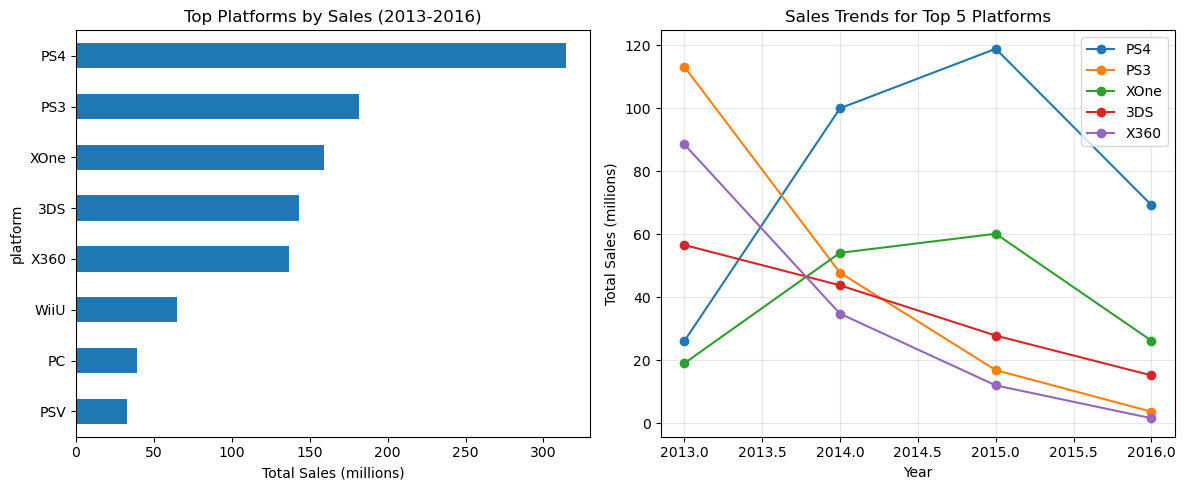

In [25]:
# Visualize top platforms
top_platforms_relevant = platform_sales_relevant.head(8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
top_platforms_relevant.plot(kind='barh')
plt.xlabel('Total Sales (millions)')
plt.title('Top Platforms by Sales (2013-2016)')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
# Calculate year-over-year growth for each platform
# Show sales trend for top 5 platforms
top_5_platforms = platform_sales_relevant.head(5).index
for platform in top_5_platforms:
    platform_yearly = df_relevant[df_relevant['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    plt.plot(platform_yearly.index, platform_yearly.values, marker='o', label=platform)

plt.xlabel('Year')
plt.ylabel('Total Sales (millions)')
plt.title('Sales Trends for Top 5 Platforms')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

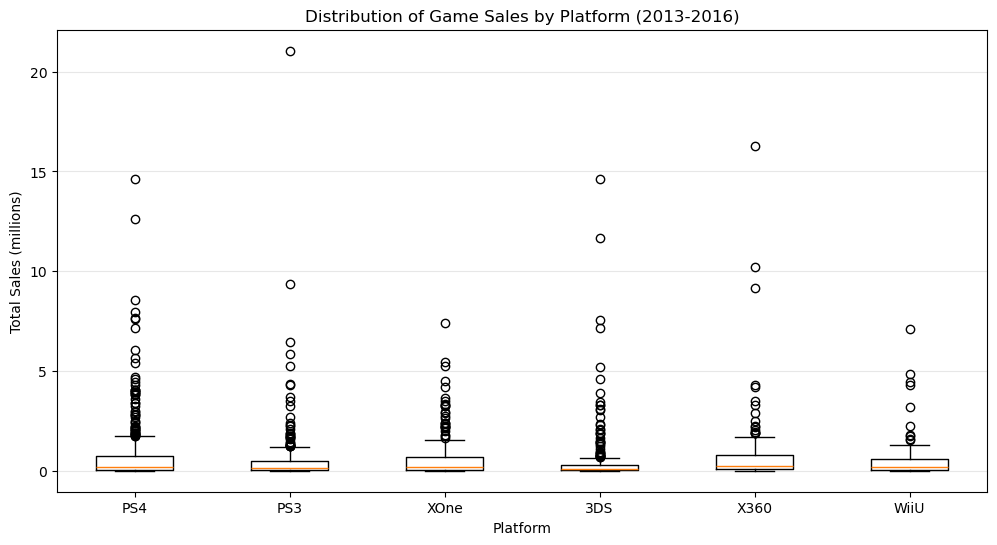

In [26]:
# Create box plot of sales by platform
# Focus on top platforms with significant data
top_platforms_for_box = platform_sales_relevant.head(6).index
plt.figure(figsize=(12, 6))
data_for_box = [df_relevant[df_relevant['platform'] == platform]['total_sales'].values for platform in top_platforms_for_box]
bp = plt.boxplot(data_for_box)
plt.xticks(range(1, len(top_platforms_for_box) + 1), top_platforms_for_box)
plt.ylabel('Total Sales (millions)')
plt.xlabel('Platform')
plt.title('Distribution of Game Sales by Platform (2013-2016)')
plt.gca().yaxis.grid(True, alpha=0.3)
plt.show()

In [27]:
# Calculate detailed statistics for each platform
print('Detailed statistics for top platforms:\n')
for platform in top_platforms_for_box:
    platform_data = df_relevant[df_relevant['platform'] == platform]['total_sales']
    print(f'{platform}:')
    print(f'  Mean: {platform_data.mean():.3f} million')
    print(f'  Median: {platform_data.median():.3f} million')
    print(f'  Std Dev: {platform_data.std():.3f} million')
    print(f'  Games: {len(platform_data)}')
    print()

Detailed statistics for top platforms:

PS4:
  Mean: 0.801 million
  Median: 0.200 million
  Std Dev: 1.609 million
  Games: 392

PS3:
  Mean: 0.526 million
  Median: 0.150 million
  Std Dev: 1.452 million
  Games: 345

XOne:
  Mean: 0.645 million
  Median: 0.220 million
  Std Dev: 1.036 million
  Games: 247

3DS:
  Mean: 0.473 million
  Median: 0.090 million
  Std Dev: 1.381 million
  Games: 303

X360:
  Mean: 0.735 million
  Median: 0.265 million
  Std Dev: 1.663 million
  Games: 186

WiiU:
  Mean: 0.562 million
  Median: 0.200 million
  Std Dev: 1.039 million
  Games: 115



## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [28]:
# Choose a popular platform based on your previous analysis
# PS4 is the leading platform in our relevant period
chosen_platform = 'PS4'
platform_df = df_relevant[df_relevant['platform'] == chosen_platform].copy()

print(f'Analyzing {chosen_platform}')
print(f'Total games: {len(platform_df)}')
print(f'Games with critic scores: {platform_df["critic_score"].notna().sum()}')
print(f'Games with user scores: {platform_df["user_score"].notna().sum()}')

Analyzing PS4
Total games: 392
Games with critic scores: 252
Games with user scores: 257


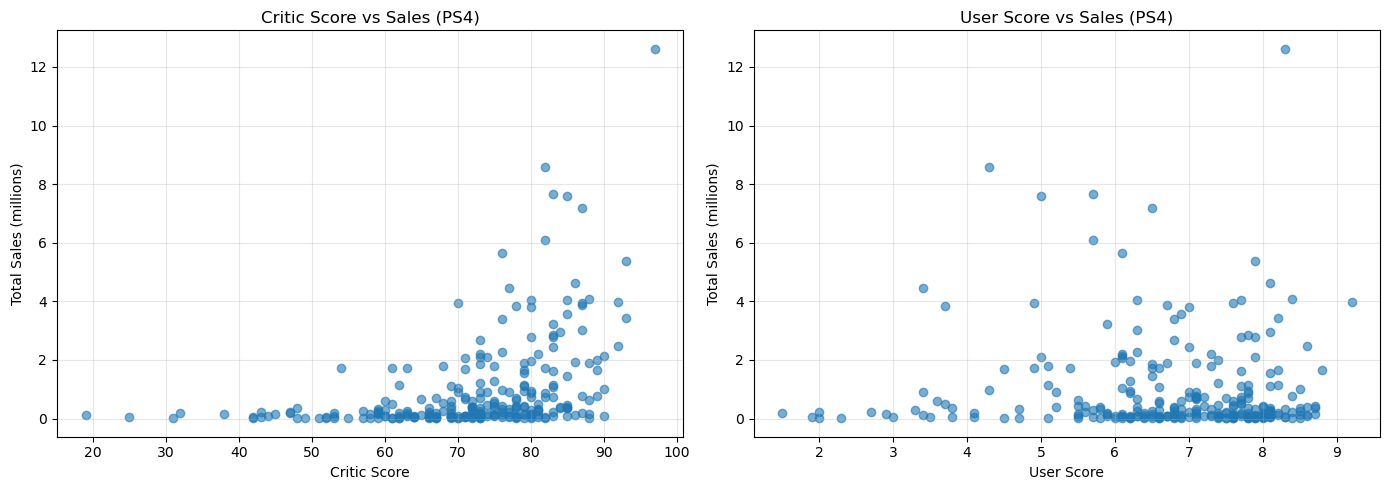


Correlation between critic score and sales: 0.407
Correlation between user score and sales: -0.032

Interpretation:
- Positive correlation means higher scores tend to have higher sales
- Values closer to 1 indicate stronger relationships
- Values closer to 0 indicate weaker relationships


In [29]:
# Create scatter plots for both critic and user scores

# Critic Scores
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Filter out rows with missing critic scores
critic_data = platform_df[platform_df['critic_score'].notna()]
plt.scatter(critic_data['critic_score'], critic_data['total_sales'], alpha=0.6)
plt.xlabel('Critic Score')
plt.ylabel('Total Sales (millions)')
plt.title(f'Critic Score vs Sales ({chosen_platform})')
plt.grid(True, alpha=0.3)

# User Scores
plt.subplot(1, 2, 2)
# Filter out rows with missing user scores
user_data = platform_df[platform_df['user_score'].notna()]
plt.scatter(user_data['user_score'], user_data['total_sales'], alpha=0.6)
plt.xlabel('User Score')
plt.ylabel('Total Sales (millions)')
plt.title(f'User Score vs Sales ({chosen_platform})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlations
critic_corr = critic_data[['critic_score', 'total_sales']].corr().iloc[0, 1]
user_corr = user_data[['user_score', 'total_sales']].corr().iloc[0, 1]

print(f'\nCorrelation between critic score and sales: {critic_corr:.3f}')
print(f'Correlation between user score and sales: {user_corr:.3f}')
print('\nInterpretation:')
print('- Positive correlation means higher scores tend to have higher sales')
print('- Values closer to 1 indicate stronger relationships')
print('- Values closer to 0 indicate weaker relationships')

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [30]:
# Find games released on multiple platforms
# Count how many platforms each game appears on
game_platforms = df_relevant.groupby('name')['platform'].nunique()
multi_platform_games = game_platforms[game_platforms > 1].sort_values(ascending=False)

print(f'Games released on multiple platforms: {len(multi_platform_games)}')
print(f'\nTop games by number of platforms:')
print(multi_platform_games.head(10))

Games released on multiple platforms: 473

Top games by number of platforms:
name
FIFA 14                              9
LEGO Marvel Super Heroes             9
FIFA 15                              8
LEGO Jurassic World                  8
Angry Birds Star Wars                8
LEGO The Hobbit                      8
Lego Batman 3: Beyond Gotham         8
The LEGO Movie Videogame             8
Skylanders: Trap Team                7
Lego Star Wars: The Force Awakens    7
Name: platform, dtype: int64


Average sales by platform for multi-platform games:
platform
PS4     0.884335
X360    0.747111
Wii     0.618636
XOne    0.603080
PS3     0.594621
3DS     0.330484
WiiU    0.321286
PC      0.208231
Name: total_sales, dtype: float64


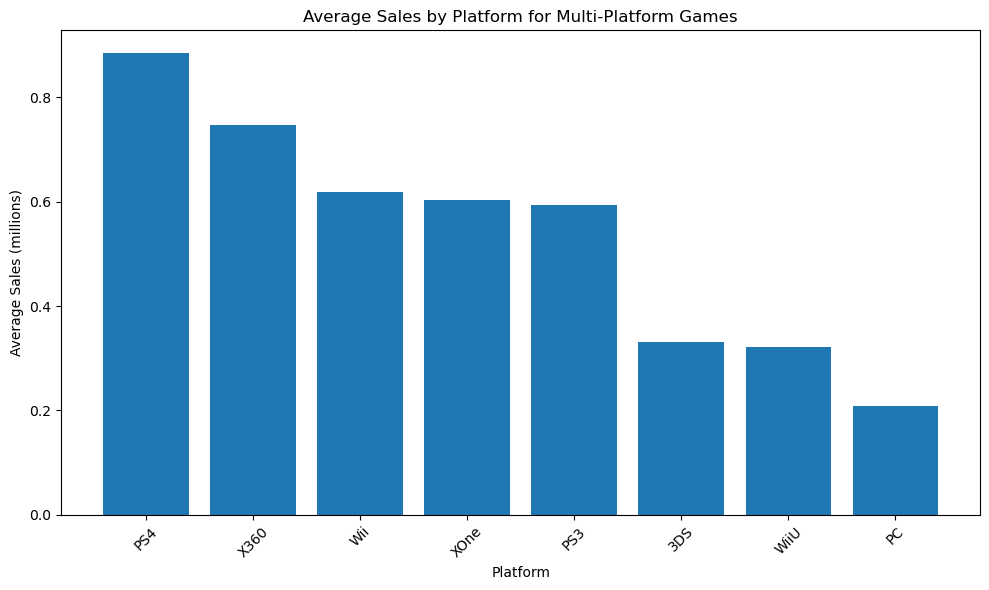

In [31]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance

# Analyze average sales across platforms for multi-platform titles
multi_platform_names = multi_platform_games.index
multi_platform_df = df_relevant[df_relevant['name'].isin(multi_platform_names)]

avg_sales_by_platform = multi_platform_df.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print('Average sales by platform for multi-platform games:')
print(avg_sales_by_platform.head(8))

# Visualize cross-platform performance
top_platforms_multi = avg_sales_by_platform.head(8)
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_platforms_multi)), top_platforms_multi.values)
plt.xticks(range(len(top_platforms_multi)), top_platforms_multi.index, rotation=45)
plt.xlabel('Platform')
plt.ylabel('Average Sales (millions)')
plt.title('Average Sales by Platform for Multi-Platform Games')
plt.tight_layout()
plt.show()

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [32]:
# Analyze genre performance
genre_analysis = df_relevant.groupby('genre').agg({
    'total_sales': ['sum', 'mean', 'count']
})
genre_analysis.columns = ['total_sales', 'avg_sales', 'num_games']
print(genre_analysis)

              total_sales  avg_sales  num_games
genre                                          
Action             321.87   0.420196        766
Adventure           23.64   0.096490        245
Fighting            35.31   0.441375         80
Misc                62.82   0.405290        155
Platform            42.63   0.576081         74
Puzzle               3.17   0.186471         17
Racing              39.89   0.469294         85
Role-Playing       145.89   0.499623        292
Shooter            232.98   1.245882        187
Simulation          21.76   0.350968         62
Sports             150.65   0.703972        214
Strategy            10.08   0.180000         56


In [33]:
# Sort genres by total sales
genre_sales = df_relevant.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print('Genres by total sales:')
print(genre_sales)

Genres by total sales:
genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64


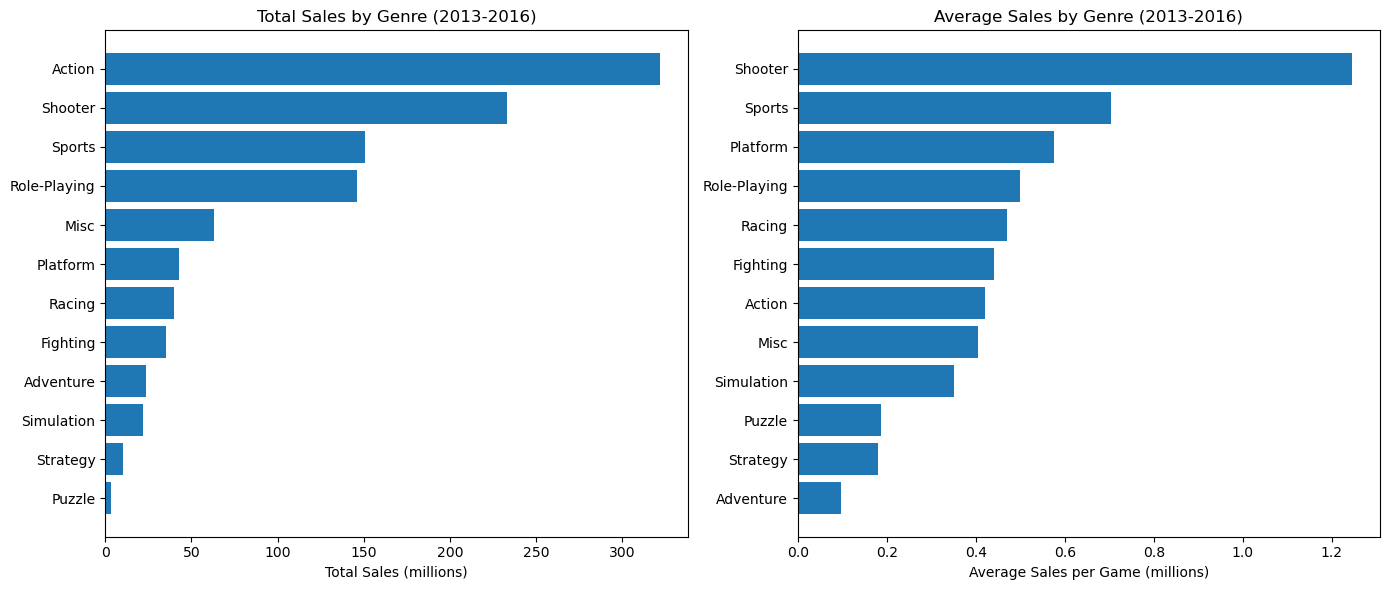

In [34]:
# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total sales by genre
axes[0].barh(genre_sales.index, genre_sales.values)
axes[0].set_xlabel('Total Sales (millions)')
axes[0].set_title('Total Sales by Genre (2013-2016)')
axes[0].invert_yaxis()

# Average sales by genre
genre_avg = df_relevant.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
axes[1].barh(genre_avg.index, genre_avg.values)
axes[1].set_xlabel('Average Sales per Game (millions)')
axes[1].set_title('Average Sales by Genre (2013-2016)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
# Calculate market share for each genre
total_sales_all_genres = genre_sales.sum()
genre_market_share = (genre_sales / total_sales_all_genres * 100).sort_values(ascending=False)

print('Market share by genre (%):')
for genre, share in genre_market_share.items():
    print(f'{genre}: {share:.2f}%')

Market share by genre (%):
Action: 29.51%
Shooter: 21.36%
Sports: 13.81%
Role-Playing: 13.38%
Misc: 5.76%
Platform: 3.91%
Racing: 3.66%
Fighting: 3.24%
Adventure: 2.17%
Simulation: 2.00%
Strategy: 0.92%
Puzzle: 0.29%


### Genre Analysis Summary:

**Which genres consistently perform well?**
- **Action** is the dominant genre with 29.51% market share and the highest total sales (321.87 million)
- **Shooter** games have the highest average sales per game (1.25 million), indicating strong individual title performance
- **Sports** and **Role-Playing** games also show strong market presence with 13-14% market share each

**Genres with high sales:**
- Shooter games have the best average performance per title despite fewer total titles (187 games)
- Sports games average 0.70 million per title with consistent demand
- Platform games show strong average sales (0.58 million) despite being a smaller market

**Genres with low sales:**
- Puzzle (0.29% market share), Strategy (0.92%), and Adventure (2.17%) have the smallest market presence
- These genres also have lower average sales per game

**General observations:**
Action and Shooter genres dominate the market and should be prioritized for advertising campaigns. High-budget shooter games tend to perform exceptionally well individually, while action games succeed through volume and variety.

## Step 4: Regional Market Analysis and User Profiles

Analyzing gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP), focusing on platform preferences, genre popularity, and ESRB ratings impact.

### 4.1 Regional Platform Analysis

Examining platform performance across different regions:

In [36]:
# Function to analyze platform performance by region
def analyze_region_platforms(region_col, region_name):
    platform_regional = df_relevant.groupby('platform')[region_col].sum().sort_values(ascending=False)
    print(f'\n{region_name} - Top 5 Platforms:')
    print(platform_regional.head(5))
    return platform_regional.head(5)

In [37]:
# Analyze each region
na_platforms = analyze_region_platforms('na_sales', 'North America')
eu_platforms = analyze_region_platforms('eu_sales', 'Europe')
jp_platforms = analyze_region_platforms('jp_sales', 'Japan')


North America - Top 5 Platforms:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Europe - Top 5 Platforms:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Japan - Top 5 Platforms:
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [38]:
# Create a comparative platform analysis
# Calculate market share for each platform in each region
regions = ['na_sales', 'eu_sales', 'jp_sales']
region_names = ['North America', 'Europe', 'Japan']

platform_shares = {}
for region, name in zip(regions, region_names):
    regional_total = df_relevant[region].sum()
    platform_regional = df_relevant.groupby('platform')[region].sum()
    platform_shares[name] = (platform_regional / regional_total * 100).sort_values(ascending=False)

# Display top 5 for each region with market share
print('\nMarket Share (%) by Region:')
for region_name in region_names:
    print(f'\n{region_name}:')
    for platform, share in platform_shares[region_name].head(5).items():
        print(f'  {platform}: {share:.2f}%')


Market Share (%) by Region:

North America:
  PS4: 24.84%
  XOne: 21.27%
  X360: 18.66%
  PS3: 14.51%
  3DS: 8.73%

Europe:
  PS4: 35.97%
  PS3: 17.29%
  XOne: 13.15%
  X360: 10.84%
  3DS: 7.89%

Japan:
  3DS: 48.17%
  PS3: 16.59%
  PSV: 13.21%
  PS4: 11.34%
  WiiU: 7.73%


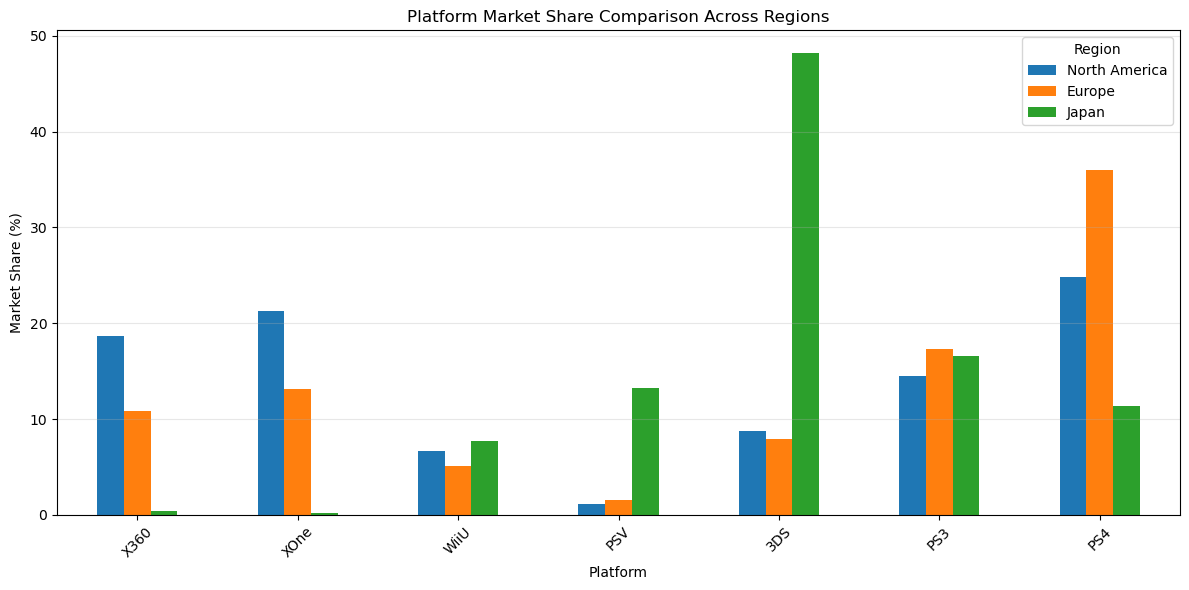

In [39]:
# Visualize cross-regional comparison for top platforms

# Get unique top platforms across all regions
top_platforms_all = set()
for name in region_names:
    top_platforms_all.update(platform_shares[name].head(5).index)

# Create comparison DataFrame
comparison_df = pd.DataFrame()
for name in region_names:
    comparison_df[name] = platform_shares[name]

comparison_df = comparison_df.loc[list(top_platforms_all)].fillna(0)

# Plot
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Platform Market Share Comparison Across Regions')
plt.xlabel('Platform')
plt.ylabel('Market Share (%)')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [40]:
# Function to analyze genre performance by region
def analyze_region_genres(region_col, region_name):
    genre_regional = df_relevant.groupby('genre')[region_col].sum().sort_values(ascending=False)
    print(f'\n{region_name} - Top 5 Genres:')
    print(genre_regional.head(5))
    return genre_regional.head(5)

# Analyze each region
na_genres = analyze_region_genres('na_sales', 'North America')
eu_genres = analyze_region_genres('eu_sales', 'Europe')
jp_genres = analyze_region_genres('jp_sales', 'Japan')


North America - Top 5 Genres:
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Europe - Top 5 Genres:
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Japan - Top 5 Genres:
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:


Genre Market Share (%) by Region:

North America:
  Action: 28.80%
  Shooter: 25.07%
  Sports: 14.91%
  Role-Playing: 10.60%
  Misc: 6.28%

Europe:
  Action: 30.12%
  Shooter: 22.40%
  Sports: 15.43%
  Role-Playing: 9.43%
  Racing: 5.15%

Japan:
  Role-Playing: 36.26%
  Action: 28.76%
  Misc: 6.54%
  Fighting: 5.43%
  Shooter: 4.70%


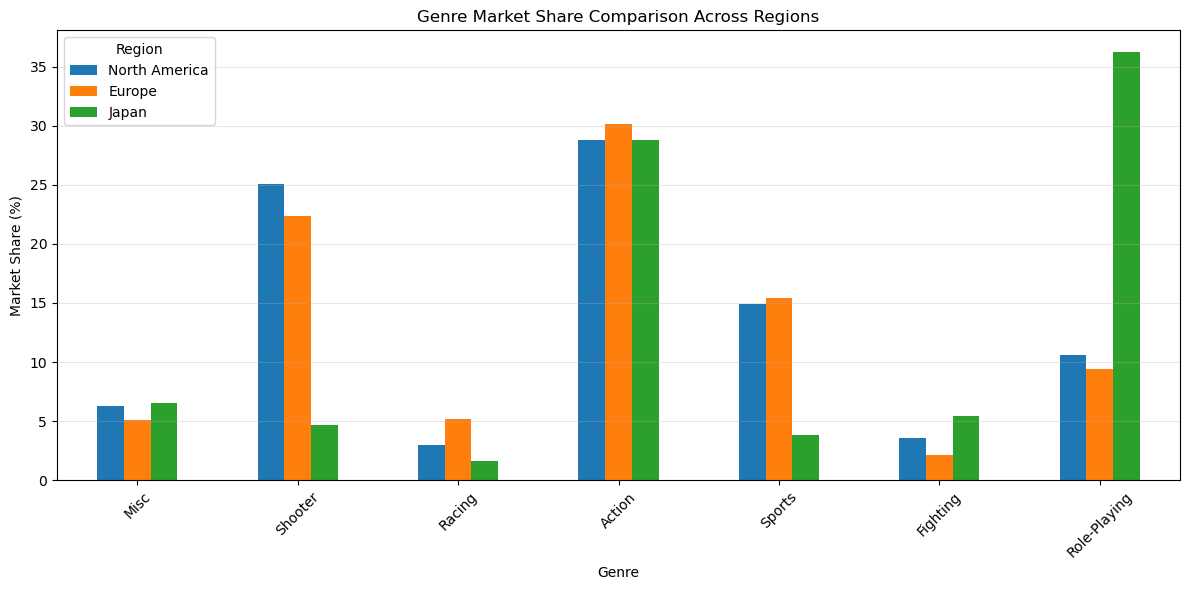

In [41]:
# Create a comparative genre analysis
genre_shares = {}
for region, name in zip(regions, region_names):
    regional_total = df_relevant[region].sum()
    genre_regional = df_relevant.groupby('genre')[region].sum()
    genre_shares[name] = (genre_regional / regional_total * 100).sort_values(ascending=False)

# Display top 5 for each region with market share
print('\nGenre Market Share (%) by Region:')
for region_name in region_names:
    print(f'\n{region_name}:')
    for genre, share in genre_shares[region_name].head(5).items():
        print(f'  {genre}: {share:.2f}%')

# Visualize
top_genres_all = set()
for name in region_names:
    top_genres_all.update(genre_shares[name].head(5).index)

comparison_genre_df = pd.DataFrame()
for name in region_names:
    comparison_genre_df[name] = genre_shares[name]

comparison_genre_df = comparison_genre_df.loc[list(top_genres_all)].fillna(0)

comparison_genre_df.plot(kind='bar', figsize=(12, 6))
plt.title('Genre Market Share Comparison Across Regions')
plt.xlabel('Genre')
plt.ylabel('Market Share (%)')
plt.legend(title='Region')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [42]:
# Function to analyze ESRB rating impact
def analyze_esrb_impact(region_col, region_name):
    # Filter out games without ratings
    rated_games = df_relevant[df_relevant['rating'].notna()]
    
    # Calculate sales by rating
    rating_sales = rated_games.groupby('rating')[region_col].sum().sort_values(ascending=False)
    
    # Calculate average sales by rating
    rating_avg = rated_games.groupby('rating')[region_col].mean().sort_values(ascending=False)
    
    print(f'\n{region_name}:')
    print(f'  Total sales by rating:')
    for rating, sales in rating_sales.items():
        print(f'    {rating}: {sales:.2f} million')
    
    print(f'  Average sales per game by rating:')
    for rating, avg in rating_avg.items():
        print(f'    {rating}: {avg:.3f} million')
    
    return rating_sales, rating_avg


North America:
  Total sales by rating:
    M: 165.21 million
    E: 79.05 million
    E10+: 54.24 million
    T: 49.79 million
  Average sales per game by rating:
    M: 0.448 million
    E: 0.262 million
    E10+: 0.215 million
    T: 0.150 million

Europe:
  Total sales by rating:
    M: 145.32 million
    E: 83.36 million
    E10+: 42.69 million
    T: 41.95 million
  Average sales per game by rating:
    M: 0.394 million
    E: 0.276 million
    E10+: 0.169 million
    T: 0.126 million

Japan:
  Total sales by rating:
    T: 20.59 million
    E: 15.14 million
    M: 14.11 million
    E10+: 5.89 million
  Average sales per game by rating:
    T: 0.062 million
    E: 0.050 million
    M: 0.038 million
    E10+: 0.023 million


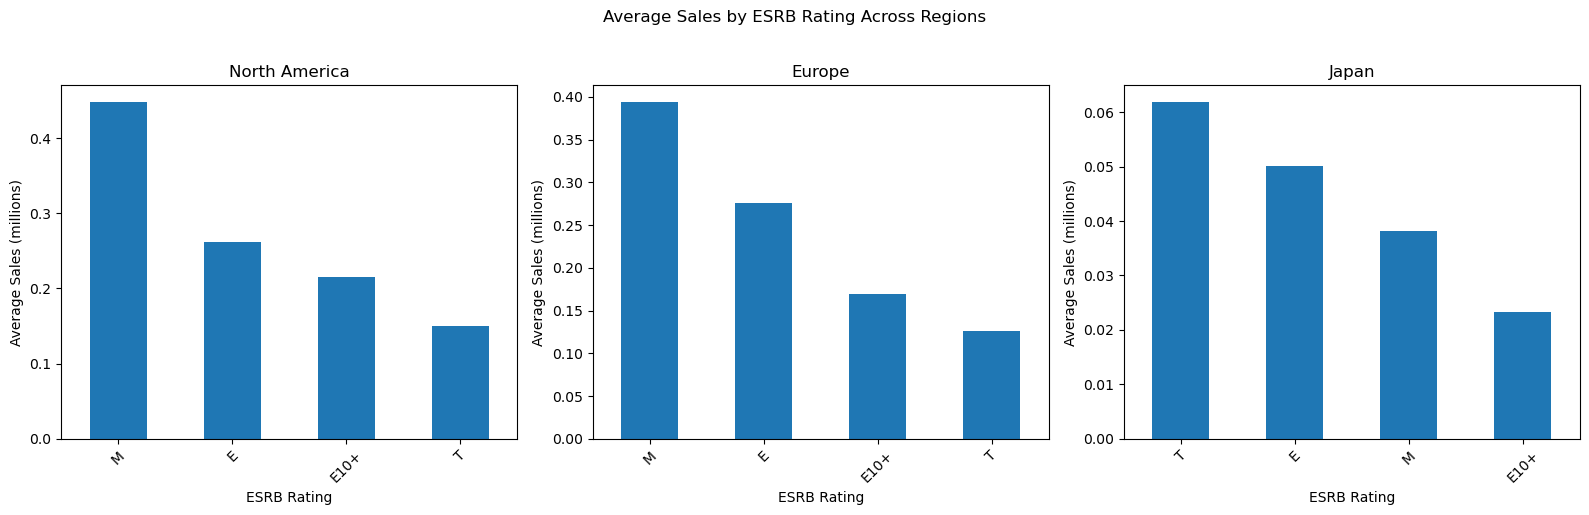

In [43]:
# Analyze ESRB impact for each region
na_rating_sales, na_rating_avg = analyze_esrb_impact('na_sales', 'North America')
eu_rating_sales, eu_rating_avg = analyze_esrb_impact('eu_sales', 'Europe')
jp_rating_sales, jp_rating_avg = analyze_esrb_impact('jp_sales', 'Japan')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

na_rating_avg.plot(kind='bar', ax=axes[0], title='North America')
axes[0].set_ylabel('Average Sales (millions)')
axes[0].set_xlabel('ESRB Rating')
axes[0].tick_params(axis='x', rotation=45)

eu_rating_avg.plot(kind='bar', ax=axes[1], title='Europe')
axes[1].set_ylabel('Average Sales (millions)')
axes[1].set_xlabel('ESRB Rating')
axes[1].tick_params(axis='x', rotation=45)

jp_rating_avg.plot(kind='bar', ax=axes[2], title='Japan')
axes[2].set_ylabel('Average Sales (millions)')
axes[2].set_xlabel('ESRB Rating')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Average Sales by ESRB Rating Across Regions', y=1.02)
plt.tight_layout()
plt.show()

### ESRB Rating Impact Analysis Summary:

**ESRB ratings do matter** and vary significantly by region

**North America:**
- **Mature (M) rated games** have the highest average sales (0.448 million per game) and total sales (165.21 million)
- ESRB ratings appear to **strongly influence** purchasing decisions - M-rated games average nearly double the sales of E-rated games
- Clear preference hierarchy: M > E > E10+ > T
- The mature gaming audience in North America drives significant revenue

**Europe:**
- Similar pattern to North America - **M-rated games lead** with 0.394 million average sales per game
- Total sales: M-rated games (145.32M) and E-rated games (83.36M) dominate the market
- European market mirrors North American preferences for mature content
- Rating hierarchy matches NA: M > E > E10+ > T

**Japan:**
- **Distinctly different** from Western markets - **T-rated games perform best** (0.062 million average, 20.59M total)
- M-rated games rank third (0.038 million average), showing Japanese market's preference for less violent/mature content
- Cultural preference for Teen-rated content over Mature content
- Rating preference: T > E > M > E10+

**Key Insights:**
- Western markets (NA/EU) favor M-rated games for higher sales
- Japan shows distinct cultural preferences favoring T-rated content
- Marketing strategies should target different ratings based on region: M for NA/EU, T for Japan

## Step 5: Hypothesis Testing

### Hypotheses to Test:
1. Average user ratings of the Xbox One and PC platforms are the same.
2. Average user ratings for the Action and Sports genres are different.

**Alpha threshold:** 0.05

**Methodology:**
- Null and alternative hypotheses formulated for each test
- Independent samples t-test used to compare means
- Missing user_score values filtered out using .notna()

### Hypothesis 1: Xbox One vs PC User Ratings

**Null Hypothesis (H₀):** The average user ratings of Xbox One and PC platforms are equal.

**Alternative Hypothesis (H₁):** The average user ratings of Xbox One and PC platforms are different.

**Test Method:** Independent samples t-test (two-tailed)
- Comparing means of two independent groups
- User ratings are continuous numerical values
- Alpha threshold: 0.05
- Variance check determines whether to use standard t-test or Welch's t-test

In [44]:
# Set alpha threshold
alpha = 0.05

# Get user ratings for both platforms (filter out missing values)
xone_ratings = df_relevant[(df_relevant['platform'] == 'XOne') & (df_relevant['user_score'].notna())]['user_score']
pc_ratings = df_relevant[(df_relevant['platform'] == 'PC') & (df_relevant['user_score'].notna())]['user_score']

print('Hypothesis 1: Average user ratings of Xbox One and PC are the same')
print(f'\nAlpha threshold: {alpha}')
print(f'\nXbox One ratings: n={len(xone_ratings)}, mean={xone_ratings.mean():.3f}, std={xone_ratings.std():.3f}')
print(f'PC ratings: n={len(pc_ratings)}, mean={pc_ratings.mean():.3f}, std={pc_ratings.std():.3f}')

# Check variance equality
xone_var = np.var(xone_ratings)
pc_var = np.var(pc_ratings)
variance_ratio = max(xone_var, pc_var) / min(xone_var, pc_var)

print(f'\nXbox One variance: {xone_var:.3f}')
print(f'PC variance: {pc_var:.3f}')
print(f'Variance ratio: {variance_ratio:.2f}')

# Determine equal_var parameter based on variance ratio
if variance_ratio < 3:
    equal_var_param = True
    print('Variances are similar - using standard t-test (equal_var=True)')
else:
    equal_var_param = False
    print('Variances differ significantly - using Welch\'s t-test (equal_var=False)')

# Perform t-test
t_stat, p_value = stats.ttest_ind(xone_ratings, pc_ratings, equal_var=equal_var_param)

print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

# Draw conclusion
if p_value < alpha:
    print(f'\nConclusion: Reject the null hypothesis (p-value {p_value:.4f} < {alpha})')
    print('The average user ratings of Xbox One and PC are statistically different.')
else:
    print(f'\nConclusion: Fail to reject the null hypothesis (p-value {p_value:.4f} >= {alpha})')
    print('There is no statistically significant difference in average user ratings between Xbox One and PC.')

Hypothesis 1: Average user ratings of Xbox One and PC are the same

Alpha threshold: 0.05

Xbox One ratings: n=182, mean=6.521, std=1.381
PC ratings: n=155, mean=6.270, std=1.742

Xbox One variance: 1.897
PC variance: 3.016
Variance ratio: 1.59
Variances are similar - using standard t-test (equal_var=True)

T-statistic: 1.4788
P-value: 0.1401

Conclusion: Fail to reject the null hypothesis (p-value 0.1401 >= 0.05)
There is no statistically significant difference in average user ratings between Xbox One and PC.


### Hypothesis 2: Action vs Sports User Ratings

**Null Hypothesis (H₀):** The average user ratings for Action and Sports genres are equal.

**Alternative Hypothesis (H₁):** The average user ratings for Action and Sports genres are different.

**Test Method:** Independent samples t-test (two-tailed)
- Comparing means of two independent groups
- User ratings are continuous numerical values
- Alpha threshold: 0.05
- Variance check determines whether to use standard t-test or Welch's t-test

In [45]:
# Get user ratings for both genres (filter out missing values)
action_ratings = df_relevant[(df_relevant['genre'] == 'Action') & (df_relevant['user_score'].notna())]['user_score']
sports_ratings = df_relevant[(df_relevant['genre'] == 'Sports') & (df_relevant['user_score'].notna())]['user_score']

print('Hypothesis 2: Average user ratings for Action and Sports genres are different')
print(f'\nAlpha threshold: {alpha}')
print(f'\nAction ratings: n={len(action_ratings)}, mean={action_ratings.mean():.3f}, std={action_ratings.std():.3f}')
print(f'Sports ratings: n={len(sports_ratings)}, mean={sports_ratings.mean():.3f}, std={sports_ratings.std():.3f}')

# Check variance equality
action_var = np.var(action_ratings)
sports_var = np.var(sports_ratings)
variance_ratio2 = max(action_var, sports_var) / min(action_var, sports_var)

print(f'\nAction variance: {action_var:.3f}')
print(f'Sports variance: {sports_var:.3f}')
print(f'Variance ratio: {variance_ratio2:.2f}')

# Determine equal_var parameter based on variance ratio
if variance_ratio2 < 3:
    equal_var_param2 = True
    print('Variances are similar - using standard t-test (equal_var=True)')
else:
    equal_var_param2 = False
    print('Variances differ significantly - using Welch\'s t-test (equal_var=False)')

# Perform t-test
t_stat2, p_value2 = stats.ttest_ind(action_ratings, sports_ratings, equal_var=equal_var_param2)

print(f'\nT-statistic: {t_stat2:.4f}')
print(f'P-value: {p_value2:.4f}')

# Draw conclusion
if p_value2 < alpha:
    print(f'\nConclusion: Reject the null hypothesis (p-value {p_value2:.4f} < {alpha})')
    print('The average user ratings for Action and Sports genres are statistically different.')
else:
    print(f'\nConclusion: Fail to reject the null hypothesis (p-value {p_value2:.4f} >= {alpha})')
    print('There is no statistically significant difference in average user ratings between Action and Sports genres.')

Hypothesis 2: Average user ratings for Action and Sports genres are different

Alpha threshold: 0.05

Action ratings: n=389, mean=6.838, std=1.330
Sports ratings: n=160, mean=5.238, std=1.783

Action variance: 1.765
Sports variance: 3.161
Variance ratio: 1.79
Variances are similar - using standard t-test (equal_var=True)

T-statistic: 11.5351
P-value: 0.0000

Conclusion: Reject the null hypothesis (p-value 0.0000 < 0.05)
The average user ratings for Action and Sports genres are statistically different.


## Step 6: General Conclusion

After conducting a comprehensive analysis of video game sales data from 2013-2016, I've identified several key patterns that will help Ice plan successful advertising campaigns for 2017:

### Platform Insights:
1. **Leading Platforms:** PS4 is the dominant and fastest-growing platform with 314 million in sales and 49% growth from early to late period. Xbox One (159M, +18% growth) is the second growing platform. PS3 (181M) and X360 (137M) have high total sales but are in steep decline (87-89% decline rates).

2. **Platform Lifecycle & Generational Transition:** Gaming platforms typically last 10-12 years before experiencing rapid decline (80-90% sales drops). Our analysis reveals a clear generational shift:
   - **Declining platforms:** PS3, X360, Wii all show 87-89% decline from 2013-2014 to 2015-2016
   - **Growing platforms:** Only PS4 (+49%) and XOne (+18%) show growth
   - **Lesson:** Previous generation consoles become irrelevant quickly once replacement generation gains traction

3. **Regional Differences:** 
   - North America prefers PS4 and Xbox One (avoid X360 - declining 89%)
   - Europe strongly favors PS4 (36% market share)
   - Japan is unique with 3DS dominating (48% market share), though 3DS also shows 57% decline

### Genre Insights:
1. **Top Genres:** Action (29.5% market share) and Shooter (21.4%) dominate globally. Shooter games have the highest average sales per title (1.25M), indicating strong individual performance.

2. **Regional Genre Preferences:**
   - North America and Europe: Action and Shooter games lead
   - Japan: Role-Playing games are #1 (36% market share), showing distinct cultural preferences

### Review Impact:
- **Critic scores** show moderate positive correlation with sales (0.407 for PS4), suggesting professional reviews influence purchasing decisions
- **User scores** show almost no correlation with sales (-0.032), which was surprising but may indicate that marketing and brand recognition matter more than user reviews

### ESRB Rating Impact:
- **Mature (M) rated games** generate the highest sales in North America and Europe
- In Japan, Teen (T) rated games perform best, reflecting different cultural preferences
- The data suggests that targeting specific age ratings based on region is important

### Recommendations for 2017 Campaign:
1. **Focus exclusively on PS4 and XOne** - these are the only growing platforms. Avoid PS3/X360 entirely (87-89% decline rates make them obsolete for 2017)
2. **PS4 is the top priority** with 49% growth momentum, especially in Europe
3. **Prioritize Action and Shooter genres** for global campaigns
4. **Customize by region:** Emphasize Xbox One in North America, PS4 in Europe, and 3DS in Japan (despite 57% decline, it still dominates Japanese market)
5. **Genre targeting:** Promote Role-Playing games specifically in Japan
6. **Feature games with high critic scores** - critic scores show moderate positive correlation with sales (0.407), so prioritize advertising games with strong critical reception
7. **Target M-rated content** in Western markets for maximum sales potential
8. **Avoid previous-generation consoles** (PS3, X360, Wii) as they are in terminal decline phase

### Hypothesis Testing Results:
- Xbox One and PC platforms have similar average user ratings (no significant difference)
- Action games receive significantly higher user ratings than Sports games, which may explain Action's market dominance

This analysis provides a data-driven foundation for identifying high-potential games and planning targeted advertising campaigns for 2017.
